# L8 · Convolution from pixels to gradients

**One running example.** We begin with one SHA-verified Oxford-IIIT Pet photograph, turn a declared crop into the same exact $5\times5$ teaching image used by the slides, and keep that image with one $3\times3$ horizontal-edge kernel through the toy calculations. You will **predict**, **calculate**, **run**, **inspect**, and **explain** each result.

By the end you should be able to:

1. compute a feature-map entry by hand;
2. implement padding and stride without a deep-learning library;
3. calculate output shapes, parameter counts, MACs, and receptive fields;
4. explain equivariance and pooling with explicit arrays;
5. verify why a shared kernel gradient sums over spatial positions.

## 0 · Bind the teaching abstraction to real evidence

Keep five evidence types separate:

- **observed:** the source photograph;
- **ground truth:** the Oxford head ROI and trimap annotation;
- **constructed:** the declared crop, grayscale bands, threshold, and binary teaching image $X$;
- **computed:** the RGB dot product, Sobel responses, shift check, pooling, and receptive-field geometry;
- **not shown:** no trained feature, saliency map, detector output, or class prediction.

The next cell reads the three small companion artifacts from a local repository checkout when available. In hosted Colab it fetches the same files from an immutable Git commit. Every byte string is checked against its recorded SHA-256 hash. It does **not** run the slide-image builder.

artifacts: SHA-256 verified (photo + trimap + XML)
photo: (400, 600, 3) | local repository: shared/vision-evidence/oxford-iiit-pet/Abyssinian_1.jpg
GT head ROI (x0,y0,x1,y1): (333, 72, 425, 158)
GT trimap counts (1=foreground, 2=background, 3=boundary): {1: 22938, 2: 198766, 3: 18296}
declared crop: (328, 120, 373, 165) shape: (45, 45, 3)
grayscale band means (0-255): [113.829 112.371 145.503 145.777 109.324]
threshold bits: [0 0 1 1 0]
constructed X =
 [[0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 0 0 0]]


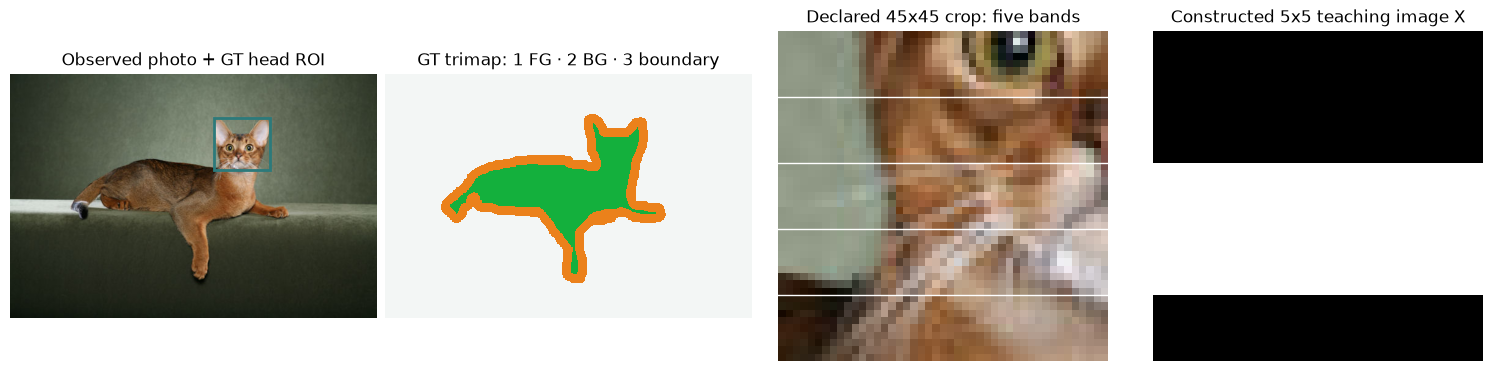

In [1]:
import hashlib
import io
import urllib.request
from pathlib import Path
from xml.etree import ElementTree

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from PIL import Image

np.set_printoptions(precision=3, suppress=True)
np.random.seed(8)

EVIDENCE_COMMIT = 'add8369838c3a0822d8de8b7dcf0294e2d8b2bf1'
EVIDENCE_REL = Path('shared/vision-evidence/oxford-iiit-pet')
ARTIFACT_SHA256 = {
    'Abyssinian_1.jpg': '2533197401eebe9410ea4d063f86c43fbd2666f3e8165a38aca155c0d09c21be',
    'Abyssinian_1-trimap.png': 'a39ce8ec0363178918cb257844125e3aa7773a3acd4ca8b84780d62c1fa6f220',
    'Abyssinian_1.xml': 'bea13ddcf1dc171e39da5ce2c134b1dc8c247a9f1bb21cc2056f37f7a423a51f',
}

def verified_artifact(name):
    expected = ARTIFACT_SHA256[name]
    local_path = next((root / EVIDENCE_REL / name for root in (Path.cwd(), *Path.cwd().parents)
                       if (root / EVIDENCE_REL / name).is_file()), None)
    if local_path is not None:
        data = local_path.read_bytes()
        origin = f'local repository: {(EVIDENCE_REL / name).as_posix()}'
    else:
        url = (f'https://raw.githubusercontent.com/nipunbatra/dl-teaching/{EVIDENCE_COMMIT}/'
               f'{EVIDENCE_REL.as_posix()}/{name}')
        with urllib.request.urlopen(url, timeout=30) as response:
            data = response.read()
        origin = f'pinned raw GitHub: {EVIDENCE_COMMIT[:8]}'
    actual = hashlib.sha256(data).hexdigest()
    assert actual == expected, f'{name}: expected {expected}, received {actual}'
    return data, origin

photo_bytes, photo_origin = verified_artifact('Abyssinian_1.jpg')
trimap_bytes, trimap_origin = verified_artifact('Abyssinian_1-trimap.png')
xml_bytes, xml_origin = verified_artifact('Abyssinian_1.xml')
photo = Image.open(io.BytesIO(photo_bytes)).convert('RGB')
photo_rgb = np.asarray(photo)
trimap = np.asarray(Image.open(io.BytesIO(trimap_bytes)), dtype=np.uint8)
xml_root = ElementTree.fromstring(xml_bytes)
box_node = xml_root.find('object/bndbox')
head_roi_xyxy = tuple(int(box_node.findtext(key)) for key in ('xmin', 'ymin', 'xmax', 'ymax'))
trimap_counts = {int(value): int((trimap == value).sum()) for value in (1, 2, 3)}

assert photo_rgb.shape == (400, 600, 3)
assert trimap.shape == (400, 600)
assert head_roi_xyxy == (333, 72, 425, 158)
assert trimap_counts == {1: 22938, 2: 198766, 3: 18296}

# Zero-based, half-open coordinates: photo_rgb[y0:y1, x0:x1].
crop_xyxy = (328, 120, 373, 165)
x0, y0, x1, y1 = crop_xyxy
crop_rgb = photo_rgb[y0:y1, x0:x1]
crop_gray_0_255 = 0.299 * crop_rgb[..., 0] + 0.587 * crop_rgb[..., 1] + 0.114 * crop_rgb[..., 2]
band_means = np.array([band.mean() for band in np.split(crop_gray_0_255, 5, axis=0)])
threshold_0_255 = 128.0
binary_rows = (band_means >= threshold_0_255).astype(int)
X_from_photo = np.repeat(binary_rows[:, None], 5, axis=1)

expected_means = np.array([113.828810, 112.371343, 145.503405, 145.776689, 109.324262])
np.testing.assert_allclose(band_means, expected_means, rtol=0, atol=5e-7)
np.testing.assert_array_equal(binary_rows, [0, 0, 1, 1, 0])
np.testing.assert_array_equal(X_from_photo, np.repeat([[0], [0], [1], [1], [0]], 5, axis=1))

print('artifacts: SHA-256 verified (photo + trimap + XML)')
print('photo:', photo_rgb.shape, '|', photo_origin)
print('GT head ROI (x0,y0,x1,y1):', head_roi_xyxy)
print('GT trimap counts (1=foreground, 2=background, 3=boundary):', trimap_counts)
print('declared crop:', crop_xyxy, 'shape:', crop_rgb.shape)
print('grayscale band means (0-255):', np.round(band_means, 6))
print('threshold bits:', binary_rows)
print('constructed X =\n', X_from_photo)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
axes[0].imshow(photo_rgb)
axes[0].add_patch(Rectangle((head_roi_xyxy[0], head_roi_xyxy[1]),
                            head_roi_xyxy[2] - head_roi_xyxy[0],
                            head_roi_xyxy[3] - head_roi_xyxy[1],
                            fill=False, edgecolor='#2c7a7b', linewidth=2))
axes[0].set_title('Observed photo + GT head ROI')
trimap_cmap = ListedColormap(['#14b03d', '#f3f6f5', '#eb811b'])
axes[1].imshow(trimap, cmap=trimap_cmap, vmin=1, vmax=3, interpolation='nearest')
axes[1].set_title('GT trimap: 1 FG · 2 BG · 3 boundary')
axes[2].imshow(crop_rgb)
for boundary in (9, 18, 27, 36):
    axes[2].axhline(boundary - 0.5, color='white', linewidth=1)
axes[2].set_title('Declared 45x45 crop: five bands')
axes[3].imshow(X_from_photo, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[3].set_title('Constructed 5x5 teaching image X')
for ax in axes:
    ax.axis('off')
plt.show()

In [2]:
# Continue with the exact teaching image constructed from the verified photo crop.
X = X_from_photo.astype(float)

K = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1],
], dtype=float)

print('X shape:', X.shape, 'K shape:', K.shape)
print('X =\n', X)
print('K =\n', K)

X shape: (5, 5) K shape: (3, 3)
X =
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]
K =
 [[ 1.  1.  1.]
 [ 0.  0.  0.]
 [-1. -1. -1.]]


## 1 · One patch, one output

The first output uses `X[0:3, 0:3]`. Before running the next cell:

- write the nine products $K[u,v]X[u,v]$;
- predict the sign of $Y[0,0]$ from the visual transition;
- calculate the exact sum.

The slide claim is $Y[0,0]=-3$: dark above, bright below.

In [3]:
patch = X[:3, :3]
products = patch * K
y00 = products.sum()

print('patch =\n', patch)
print('elementwise products =\n', products)
print('row sums =', products.sum(axis=1))
print('Y[0,0] =', y00)
assert y00 == -3

patch =
 [[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]
elementwise products =
 [[ 0.  0.  0.]
 [ 0.  0.  0.]
 [-1. -1. -1.]]
row sums = [ 0.  0. -3.]
Y[0,0] = -3.0


## 2 · Implement the sliding operation

For one input channel and one kernel, PyTorch's so-called convolution is cross-correlation:

$$Y[i,j]=\sum_{u,v}K[u,v]X[i\,s+u-p,\;j\,s+v-p].$$

Read the loops below before running them. Identify where **padding**, **stride**, and **weight sharing** appear.

In [4]:
def out_size(length, kernel, padding=0, stride=1):
    numerator = length + 2 * padding - kernel
    if numerator < 0:
        raise ValueError('kernel does not fit the padded input')
    return numerator // stride + 1

def conv2d_single(X, K, padding=0, stride=1):
    H, W = X.shape
    kh, kw = K.shape
    Hout = out_size(H, kh, padding, stride)
    Wout = out_size(W, kw, padding, stride)
    Xpad = np.pad(X, ((padding, padding), (padding, padding)))
    Y = np.empty((Hout, Wout), dtype=float)

    for i in range(Hout):
        for j in range(Wout):
            r, c = i * stride, j * stride
            patch = Xpad[r:r+kh, c:c+kw]
            Y[i, j] = np.sum(patch * K)  # the same K at every (i, j)
    return Y


### Predict the full feature map

Without running code, answer:

1. What output shape follows from $H=W=5$, $k=3$, $p=0$, $s=1$?
2. Will each row of the output be constant across columns? Why?
3. Which output row should be positive?

Now reveal the result.

Y =
 [[-3. -3. -3.]
 [-3. -3. -3.]
 [ 3.  3.  3.]]


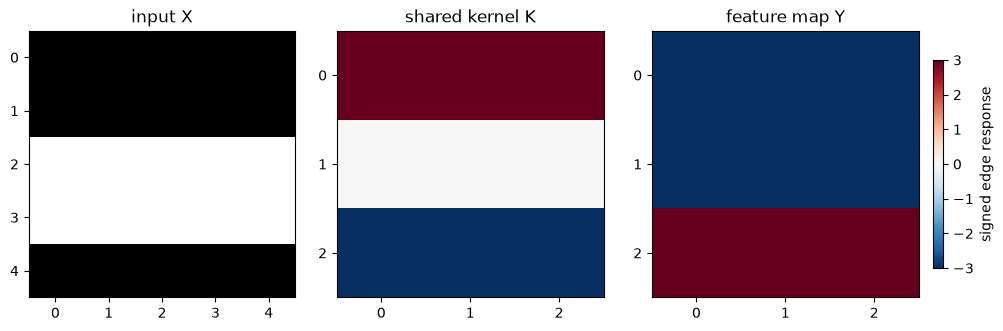

In [5]:
Y = conv2d_single(X, K)
expected = np.array([[-3, -3, -3], [-3, -3, -3], [3, 3, 3]], dtype=float)
np.testing.assert_array_equal(Y, expected)
print('Y =\n', Y)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
im0 = ax[0].imshow(X, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('input X')
im1 = ax[1].imshow(K, cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set_title('shared kernel K')
im2 = ax[2].imshow(Y, cmap='RdBu_r', vmin=-3, vmax=3)
ax[2].set_title('feature map Y')
for a in ax:
    a.set_xticks(range(a.images[0].get_array().shape[1]))
    a.set_yticks(range(a.images[0].get_array().shape[0]))
    a.grid(False)
fig.colorbar(im2, ax=ax[2], shrink=0.78, label='signed edge response')
plt.show()

### Inspect the sharing explicitly

The next cell prints three patches from the slide sequence. Explain why the kernel values never appear inside the loop as position-specific parameters.

In [6]:
for i, j in [(0, 0), (0, 1), (2, 0)]:
    patch = X[i:i+3, j:j+3]
    print(f'output ({i},{j})')
    print(patch)
    print('dot with the SAME K ->', np.sum(patch * K), '\n')

output (0,0)
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]
dot with the SAME K -> -3.0 

output (0,1)
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]
dot with the SAME K -> -3.0 

output (2,0)
[[1. 1. 1.]
 [1. 1. 1.]
 [0. 0. 0.]]
dot with the SAME K -> 3.0 



## 3 · Output geometry: count legal starts

$$H_{out}=\left\lfloor\frac{H+2p-k}{s}\right\rfloor+1.$$

Predict all four outputs below before running the tests. For the final case, list the legal start positions explicitly.

In [7]:
cases = [
    # H, k, p, s, expected
    (5, 3, 0, 1, 3),
    (5, 3, 1, 1, 5),
    (7, 3, 1, 2, 4),
    (8, 3, 0, 2, 3),
]
for H, k, p, s, expected in cases:
    got = out_size(H, k, p, s)
    starts = list(range(0, H + 2*p - k + 1, s))
    print(f'H={H}, k={k}, p={p}, s={s}: starts={starts}, Hout={got}')
    assert got == expected == len(starts)

H=5, k=3, p=0, s=1: starts=[0, 1, 2], Hout=3
H=5, k=3, p=1, s=1: starts=[0, 1, 2, 3, 4], Hout=5
H=7, k=3, p=1, s=2: starts=[0, 2, 4, 6], Hout=4
H=8, k=3, p=0, s=2: starts=[0, 2, 4], Hout=3


### See padding and stride change different things

Padding changes which border patches are legal. Stride selects a subset of legal starts. Predict each output shape and then inspect the arrays.

In [8]:
for padding, stride in [(0, 1), (1, 1), (1, 2)]:
    out = conv2d_single(X, K, padding=padding, stride=stride)
    print(f'p={padding}, s={stride}, shape={out.shape}')
    print(out, '\n')

p=0, s=1, shape=(3, 3)
[[-3. -3. -3.]
 [-3. -3. -3.]
 [ 3.  3.  3.]] 

p=1, s=1, shape=(5, 5)
[[ 0.  0.  0.  0.  0.]
 [-2. -3. -3. -3. -2.]
 [-2. -3. -3. -3. -2.]
 [ 2.  3.  3.  3.  2.]
 [ 2.  3.  3.  3.  2.]] 

p=1, s=2, shape=(3, 3)
[[ 0.  0.  0.]
 [-2. -3. -2.]
 [ 2.  3.  2.]] 



## 4 · Channels and parameter counts

A $1\times1$ RGB kernel still spans all three channels. Use the actual photo pixel at zero-based $(x,y)=(373,137)$: its 8-bit value is $(131,66,60)$. The illustrative teaching kernel is $w=(0.5,-1,0.4)$; it is not a trained filter. Predict the output before running.

In [9]:
pixel_xy = (373, 137)
rgb_8bit = photo_rgb[pixel_xy[1], pixel_xy[0]].astype(int)
rgb = rgb_8bit / 255.0
weights = np.array([0.5, -1.0, 0.4])
contributions = rgb * weights
print('pixel (x,y):', pixel_xy, 'RGB 8-bit:', rgb_8bit)
print('normalized RGB:', rgb)
print('channel contributions:', contributions)
print('sum:', contributions.sum())
np.testing.assert_array_equal(rgb_8bit, [131, 66, 60])
np.testing.assert_allclose(contributions, [131/510, -22/85, 8/85], rtol=0, atol=1e-12)
assert np.isclose(contributions.sum(), 47/510, rtol=0, atol=1e-12)

pixel (x,y): (373, 137) RGB 8-bit: [131  66  60]
normalized RGB: [0.514 0.259 0.235]
channel contributions: [ 0.257 -0.259  0.094]
sum: 0.09215686274509799


In [10]:
def conv_params(kh, kw, c_in, c_out, bias=True):
    return kh * kw * c_in * c_out + (c_out if bias else 0)

def conv_macs(h_out, w_out, kh, kw, c_in, c_out):
    return h_out * w_out * c_out * kh * kw * c_in

# The exact tiny CNN from the slides
p1 = conv_params(3, 3, 3, 16)
p2 = conv_params(3, 3, 16, 32)
p_head = 32 * 10 + 10
m1 = conv_macs(32, 32, 3, 3, 3, 16)
m2 = conv_macs(16, 16, 3, 3, 16, 32)
m_head = 32 * 10

print(f'parameters: conv1={p1:,}, conv2={p2:,}, head={p_head:,}, total={p1+p2+p_head:,}')
print(f'MACs:       conv1={m1:,}, conv2={m2:,}, head={m_head:,}, total={m1+m2+m_head:,}')
assert (p1 + p2 + p_head) == 5_418
assert (m1 + m2 + m_head) == 1_622_336

parameters: conv1=448, conv2=4,640, head=330, total=5,418
MACs:       conv1=442,368, conv2=1,179,648, head=320, total=1,622,336


**Explain in one sentence:** Why does doubling image height and width leave `p1` unchanged but make `m1` approximately four times larger?

## 5 · Equivariance and pooling

A shared convolution should move its response when the input moves. Exact comparisons require care at boundaries. We compare the valid interior below.

In [11]:
signal = np.array([0., 1., 1., 0., 0., 0.])
kernel_1d = np.array([-1., 0., 1.])

def corr1d(x, k):
    return np.array([np.dot(x[i:i+len(k)], k) for i in range(len(x)-len(k)+1)])

shifted = np.r_[0., signal[:-1]]
f = corr1d(signal, kernel_1d)
f_shifted = corr1d(shifted, kernel_1d)
print('x:              ', signal)
print('shift(x):       ', shifted)
print('f(x):           ', f)
print('f(shift(x)):    ', f_shifted)
print('shift(f(x)):    ', np.r_[0., f[:-1]])
np.testing.assert_allclose(f_shifted[1:], f[:-1])

x:               [0. 1. 1. 0. 0. 0.]
shift(x):        [0. 0. 1. 1. 0. 0.]
f(x):            [ 1. -1. -1.  0.]
f(shift(x)):     [ 1.  1. -1. -1.]
shift(f(x)):     [ 0.  1. -1. -1.]


### Real-image operator evidence

The exact 1-D trace above remains the proof. Now compute the same spatial ideas on the verified photograph: resize to $300\times200$, use grayscale $0.299R+0.587G+0.114B$, apply **valid cross-correlation** with the displayed Sobel-x kernel, repeat after a zero-filled 12-pixel right shift, then pool $|\text{response}|$. Predict the response and pooled shapes first. These are deterministic operator outputs—not learned feature maps or predictions.

real Sobel response shape: (198, 298)
shifted response shape: (198, 298)
2x2 stride-2 max-pooled |response| shape: (99, 149)
shared-interior max |difference|: 1.3877787807814457e-17


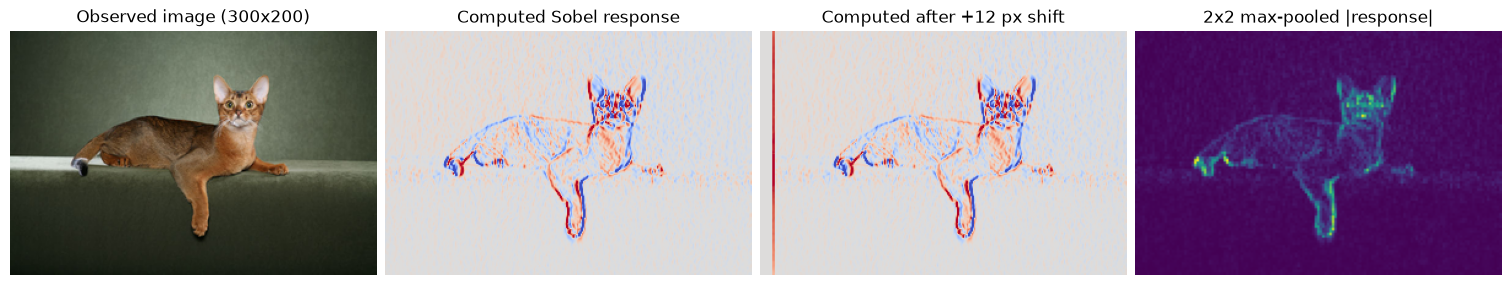

In [12]:
def corr2d_valid(values, kernel):
    windows = np.lib.stride_tricks.sliding_window_view(values, kernel.shape)
    return np.einsum('ijuv,uv->ij', windows, kernel, optimize=True)

def max_pool_2x2_stride2(values):
    height = values.shape[0] // 2 * 2
    width = values.shape[1] // 2 * 2
    windows = np.lib.stride_tricks.sliding_window_view(values[:height, :width], (2, 2))[::2, ::2]
    return windows.max(axis=(-2, -1))

work_rgb = np.asarray(photo.resize((300, 200), Image.Resampling.LANCZOS), dtype=float)
work_gray = (0.299 * work_rgb[..., 0] + 0.587 * work_rgb[..., 1] + 0.114 * work_rgb[..., 2]) / 255.0
sobel_x = np.array([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]])
real_response = corr2d_valid(work_gray, sobel_x)
shift_pixels = 12
shifted_gray = np.zeros_like(work_gray)
shifted_gray[:, shift_pixels:] = work_gray[:, :-shift_pixels]
shifted_real_response = corr2d_valid(shifted_gray, sobel_x)
pooled_abs_response = max_pool_2x2_stride2(np.abs(real_response))

assert real_response.shape == (198, 298)
assert shifted_real_response.shape == (198, 298)
assert pooled_abs_response.shape == (99, 149)
# A valid 3x3 response at output column j uses input columns j:j+3.
# After a +12 input shift, columns 12 onward reproduce columns 0 onward exactly.
np.testing.assert_allclose(shifted_real_response[:, shift_pixels:],
                           real_response[:, :-shift_pixels], rtol=0, atol=1e-12)

print('real Sobel response shape:', real_response.shape)
print('shifted response shape:', shifted_real_response.shape)
print('2x2 stride-2 max-pooled |response| shape:', pooled_abs_response.shape)
print('shared-interior max |difference|:',
      np.max(np.abs(shifted_real_response[:, shift_pixels:] - real_response[:, :-shift_pixels])))

signed_scale = np.percentile(
    np.abs(np.r_[real_response.ravel(), shifted_real_response.ravel()]), 99)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), constrained_layout=True)
axes[0].imshow(work_rgb.astype(np.uint8))
axes[0].set_title('Observed image (300x200)')
axes[1].imshow(real_response, cmap='coolwarm', vmin=-signed_scale, vmax=signed_scale)
axes[1].set_title('Computed Sobel response')
axes[2].imshow(shifted_real_response, cmap='coolwarm', vmin=-signed_scale, vmax=signed_scale)
axes[2].set_title('Computed after +12 px shift')
axes[3].imshow(pooled_abs_response, cmap='viridis')
axes[3].set_title('2x2 max-pooled |response|')
for ax in axes:
    ax.axis('off')
plt.show()

In [13]:
def pool2d(X, window=2, stride=2, mode='max'):
    Hout = out_size(X.shape[0], window, 0, stride)
    Wout = out_size(X.shape[1], window, 0, stride)
    Y = np.empty((Hout, Wout))
    reduce = np.max if mode == 'max' else np.mean
    for i in range(Hout):
        for j in range(Wout):
            patch = X[i*stride:i*stride+window, j*stride:j*stride+window]
            Y[i, j] = reduce(patch)
    return Y

F = np.array([[1,3,2,4], [5,6,1,2], [7,2,3,0], [1,0,4,8]], dtype=float)
print('max pool =\n', pool2d(F, mode='max'))
print('avg pool =\n', pool2d(F, mode='avg'))
print('global average =', F.mean())

max pool =
 [[6. 4.]
 [7. 8.]]
avg pool =
 [[3.75 2.25]
 [2.5  3.75]]
global average = 3.0625


**Explain:** Move the value `6` to a different location inside the same top-left $2\times2$ window. Which pooled outputs remain unchanged? What changes if it crosses into the top-right window?

## 6 · Receptive field and jump

Track $(r,j)$, where $r$ is receptive-field width and $j$ is spacing between adjacent feature-map units in original input pixels:

$$j_l=j_{l-1}s_l,\qquad r_l=r_{l-1}+(k_l-1)j_{l-1}.$$

Predict the rows for `conv3-s1 → pool2-s2 → conv3-s1` before running. The $r=3,4,8$ photo boxes in the slides use one common display scale; they show theoretical input support, not saliency or learned importance.

In [14]:
def receptive_field(layers):
    r, j = 1, 1
    rows = [('input', 1, 1, r, j)]
    for name, k, s in layers:
        r = r + (k - 1) * j
        j = j * s
        rows.append((name, k, s, r, j))
    return rows

layers = [('conv1', 3, 1), ('pool', 2, 2), ('conv2', 3, 1)]
print('layer     k  s  r  j')
rf_rows = receptive_field(layers)
for name, k, s, r, j in rf_rows:
    print(f'{name:8s} {k:2d} {s:2d} {r:2d} {j:2d}')
assert [row[3] for row in rf_rows[1:]] == [3, 4, 8]
assert rf_rows[-1][-2:] == (8, 2)
rf_display_sides = np.array([3, 4, 8]) * 16
np.testing.assert_array_equal(rf_display_sides, [48, 64, 128])
print('photo-overlay display sides:', rf_display_sides, '(theoretical support; not saliency)')

layer     k  s  r  j
input     1  1  1  1
conv1     3  1  3  1
pool      2  2  4  2
conv2     3  1  8  2
photo-overlay display sides: [ 48  64 128] (theoretical support; not saliency)


## 7 · Backprop through shared weights

Use the exact slide example: $x=(2,1,3)$, $k=(0.5,-1)$, $b=0$, and arriving gradient $g=(1,2)$.

Before running, calculate:

- $y_0,y_1$;
- $\partial L/\partial k_0$ and $\partial L/\partial k_1$;
- $\partial L/\partial x_0,\partial L/\partial x_1,\partial L/\partial x_2$;
- $\partial L/\partial b$.

In [15]:
x = np.array([2., 1., 3.])
k = np.array([0.5, -1.])
g = np.array([1., 2.])
b = 0.

y = corr1d(x, k) + b
grad_k = np.array([g[0]*x[0] + g[1]*x[1],
                   g[0]*x[1] + g[1]*x[2]])
grad_x = np.array([g[0]*k[0],
                   g[0]*k[1] + g[1]*k[0],
                   g[1]*k[1]])
grad_b = g.sum()

print('y      =', y)
print('grad_k =', grad_k)
print('grad_x =', grad_x)
print('grad_b =', grad_b)
np.testing.assert_allclose(y, [0., -2.5])
np.testing.assert_allclose(grad_k, [4., 7.])
np.testing.assert_allclose(grad_x, [0.5, 0., -2.])
assert grad_b == 3

y      = [ 0.  -2.5]
grad_k = [4. 7.]
grad_x = [ 0.5  0.  -2. ]
grad_b = 3.0


In [16]:
import torch
import torch.nn.functional as F

xt = torch.tensor(x[None, None, :], dtype=torch.float64, requires_grad=True)
kt = torch.tensor(k[None, None, :], dtype=torch.float64, requires_grad=True)
bt = torch.tensor([b], dtype=torch.float64, requires_grad=True)
gt = torch.tensor(g, dtype=torch.float64)[None, None, :]
yt = F.conv1d(xt, kt, bt)
yt.backward(gt)

print('PyTorch y      =', yt.detach().numpy().ravel())
print('PyTorch grad_k =', kt.grad.numpy().ravel())
print('PyTorch grad_x =', xt.grad.numpy().ravel())
print('PyTorch grad_b =', bt.grad.numpy())
np.testing.assert_allclose(kt.grad.numpy().ravel(), grad_k)
np.testing.assert_allclose(xt.grad.numpy().ravel(), grad_x)
np.testing.assert_allclose(bt.grad.numpy(), [grad_b])

PyTorch y      = [ 0.  -2.5]
PyTorch grad_k = [4. 7.]
PyTorch grad_x = [ 0.5  0.  -2. ]
PyTorch grad_b = [3.]


### Independent finite-difference check

Define a scalar $L=g^Ty$. A central difference perturbs one shared kernel value and automatically changes **both** output positions.

In [17]:
def scalar_loss(k_value):
    return np.dot(g, corr1d(x, k_value) + b)

eps = 1e-6
grad_fd = np.empty_like(k)
for q in range(len(k)):
    direction = np.zeros_like(k)
    direction[q] = eps
    grad_fd[q] = (scalar_loss(k + direction) - scalar_loss(k - direction)) / (2*eps)
print('finite-difference grad_k =', grad_fd)
np.testing.assert_allclose(grad_fd, grad_k, rtol=1e-8, atol=1e-8)

finite-difference grad_k = [4. 7.]


## 8 · Build the exact tiny CNN from the slides

The slides write one image in mathematical $H \times W \times C$ order, here $32 \times 32 \times 3$. PyTorch `Conv2d` expects a batch in $N \times C \times H \times W$ order, so the same input has shape `(1, 3, 32, 32)` below.

Predict each activation shape and the total parameter count before running. This model cell trains nothing and performs no additional download; the only external evidence used earlier is one tiny SHA-checked companion sample with its two annotations.

In [18]:
from torch import nn

torch.manual_seed(8)
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(32, 10),
)

h = torch.randn(1, 3, 32, 32)
print('input'.ljust(22), tuple(h.shape))
for layer in model:
    h = layer(h)
    print(layer.__class__.__name__.ljust(22), tuple(h.shape))

total = sum(p.numel() for p in model.parameters())
print('total parameters:', total)
assert tuple(h.shape) == (1, 10)
assert total == 5_418

input                  (1, 3, 32, 32)
Conv2d                 (1, 16, 32, 32)
ReLU                   (1, 16, 32, 32)
MaxPool2d              (1, 16, 16, 16)
Conv2d                 (1, 32, 16, 16)
ReLU                   (1, 32, 16, 16)
AdaptiveAvgPool2d      (1, 32, 1, 1)
Flatten                (1, 32)
Linear                 (1, 10)
total parameters: 5418


## Explain before you leave

Write a short answer to each prompt without using the words *because convolution is good for images*:

1. Why does a convolution have few parameters but potentially many MACs?
2. Why is a feature map equivariant rather than invariant to translation?
3. How can stride make receptive fields grow faster?
4. Why does `grad_k` add contributions from multiple output positions?
5. Which information does global average pooling deliberately discard?
6. For the real sample, which quantities are observed, ground truth, constructed, computed, and not shown?

**Core mental model:** a kernel is one learned local question, asked everywhere; depth composes the spatial answers into task evidence.